# N-Qubit W-State Preparation (F-gate method) with Optimal Qubit Selection

The **W state** for $N$ qubits is:

$$|W_N\rangle = \frac{1}{\sqrt{N}}\sum_{k=0}^{N-1}|0\cdots 1_k \cdots 0\rangle$$

Unlike the GHZ state, the W state survives qubit loss: tracing out any one qubit leaves the remaining $N-1$ in an entangled mixed state.

### What we'll do
1. Build the $N$-qubit W-state circuit using the **F-gate (Diker) method** — scales linearly in gate count, uses only 2-qubit gates
2. Use the **IQM Qubit Selector** to pick the optimal $N$-qubit subset on the hardware
3. Run on IQM Resonance with configurable shots
4. Demonstrate non-linear entanglement correlations:
   - In the **Z basis**: each qubit is excited with probability $1/N$; joint excitation is forbidden
   - In the **X basis**: two-body correlator $\langle X_i X_j \rangle = 2/N$ for the quantum W state vs. $0$ for any classical mixture
   - This gap is a fingerprint of genuine quantum entanglement

> **Shot budget note:** With `SHOTS = 10` and `N_QUBITS = 10` the Z-basis pattern is visible but the X-basis correlators (signal $= 2/N = 0.2$) are buried under shot noise ($\approx 1/\sqrt{10} \approx 0.32$). Increase `SHOTS` to ≥ 200 for statistically meaningful correlators.


## 1. Install required packages

In [4]:
!pip install --upgrade pip
!pip install "iqm-client[qiskit]"
!pip install iqm-qubit-selector
!pip install matplotlib numpy scipy qiskit-aer pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 52.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 58.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 115.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 108.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 604.8/604.8 kB 18.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 119.1 MB/s  0:00:00
  Attempting uninstall: pydantic-core━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  5/32 [python-rapidjson]
    Found existing installation: pydantic_core 2.41.4━━━━━━━━━  5/32 [pytho

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 73.3 MB/s  0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136897 sha256=5d0a4739543d3f0a7d99fb0dacd9c91702fafcb4e7cf99a88e497313f21d319b
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [iqm-qubit-selector]qm-pulla]


In [5]:
# ── Experiment configuration ─────────────────────────────────────────────────
N_QUBITS = 30   # W-state size (try 3–15; hardware fidelity drops for large N)
SHOTS    = 200   # shots per circuit (10 = minimal credit; ≥200 for reliable X-correlators)


## 2. Connect to IQM Resonance

In [ ]:
import os
from pathlib import Path
from iqm.qiskit_iqm import IQMProvider

# Prefer IQM_TOKEN env var; fall back to .secrets/iqm_api_key at cwd or repo root
api_token = os.environ.get("IQM_TOKEN")
if not api_token:
    for p in [Path.cwd()/'.secrets'/'iqm_api_key', Path.cwd().parent/'.secrets'/'iqm_api_key']:
        if p.exists():
            api_token = p.read_text().strip()
            print(f"Using token from {p}")
            break
if not api_token:
    raise RuntimeError("Set IQM_TOKEN env var or place token in .secrets/iqm_api_key")
os.environ["IQM_TOKEN"] = api_token

# Emerald: 54-qubit chip well-suited for multi-qubit entanglement
provider = IQMProvider("https://resonance.meetiqm.com",
                       quantum_computer="emerald")
backend = provider.get_backend()
print(f"Connected to {backend.name} ({backend.num_qubits} qubits)")

## 3. Visualize device topology

Understanding the qubit connectivity is crucial — two-qubit gates are only natively available between connected qubits. Extra SWAP gates added during routing degrade fidelity.

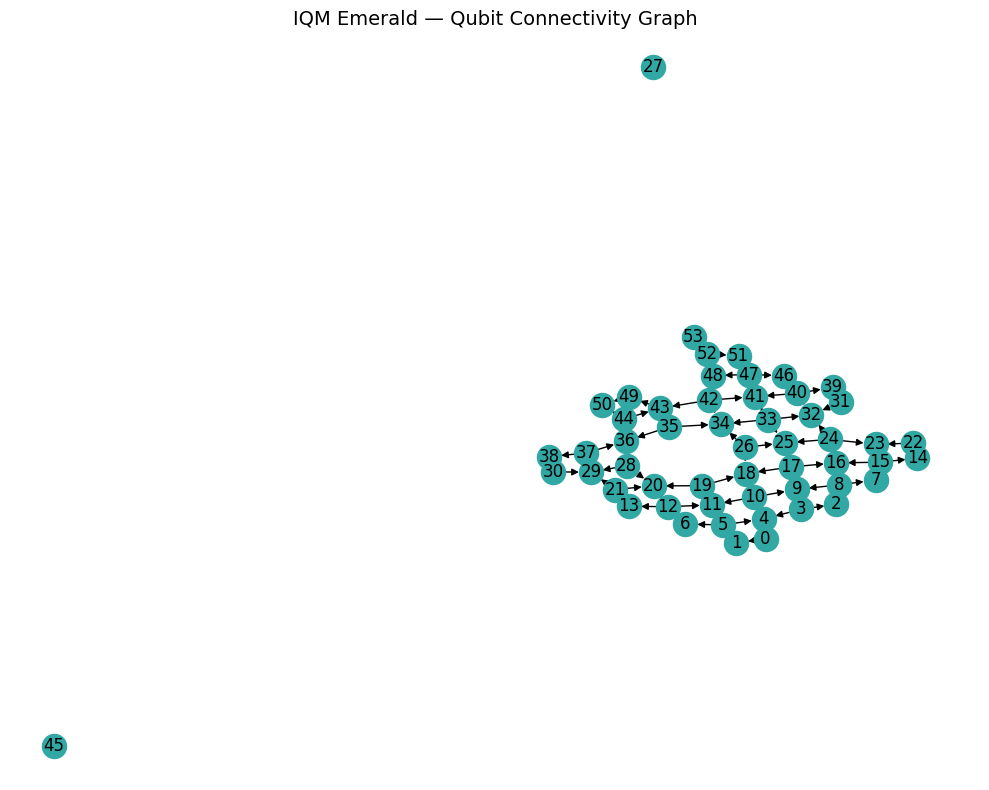

In [ ]:
import matplotlib.pyplot as plt
from rustworkx.visualization import mpl_draw
from rustworkx import spring_layout

fig, ax = plt.subplots(figsize=(10, 8))
mpl_draw(
    backend.coupling_map.graph,
    ax=ax,
    arrows=True,
    with_labels=True,
    node_color='#32a8a4',
    pos=spring_layout(backend.coupling_map.graph, num_iter=500)
)
ax.set_title("IQM Emerald — Qubit Connectivity Graph", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Build the N-qubit W-state circuit (F-gate method)

The **F-gate (Diker 2016)** preparation uses only single-qubit Ry rotations and two-qubit CZ/CNOT gates, scaling linearly to any $N$:

**Algorithm** — starting from $|10\cdots0\rangle$:

1. **F-gate chain** ($N-1$ gates): For $k = 1, \ldots, N-1$ apply $F_k$ between $q_{k-1}$ (control) and $q_k$ (target), where $F_k = R_y(-\theta_k) \cdot CZ \cdot R_y(+\theta_k)$ and $\theta_k = \arccos\!\sqrt{\tfrac{1}{N-k+1}}$. The F-gate acts as:
   - control $= 0$: identity on target (no-op)
   - control $= 1$: target $|0\rangle \to \cos\theta_k|0\rangle + \sin\theta_k|1\rangle$

   After the chain the state is $\frac{1}{\sqrt{N}}\sum_{j=0}^{N-1}|1\cdots 1_j 0\cdots 0\rangle$ — equal-weight superposition of all "filled-prefix" strings.

2. **CNOT correction** ($N-1$ gates): For $k = 0, \ldots, N-2$ apply $\text{CNOT}(q_{k+1}, q_k)$. Each CNOT collapses the filled prefix into a single-excitation string, converting to $|W_N\rangle$.

**Total:** $(N-1)$ F-gates $\times$ 3 elementary gates + $(N-1)$ CNOTs $= O(N)$ gates, all 2-qubit.


W30 circuit: 30 qubits, depth 60, OrderedDict({'ry': 58, 'cz': 29, 'cx': 29, 'x': 1}) gate types


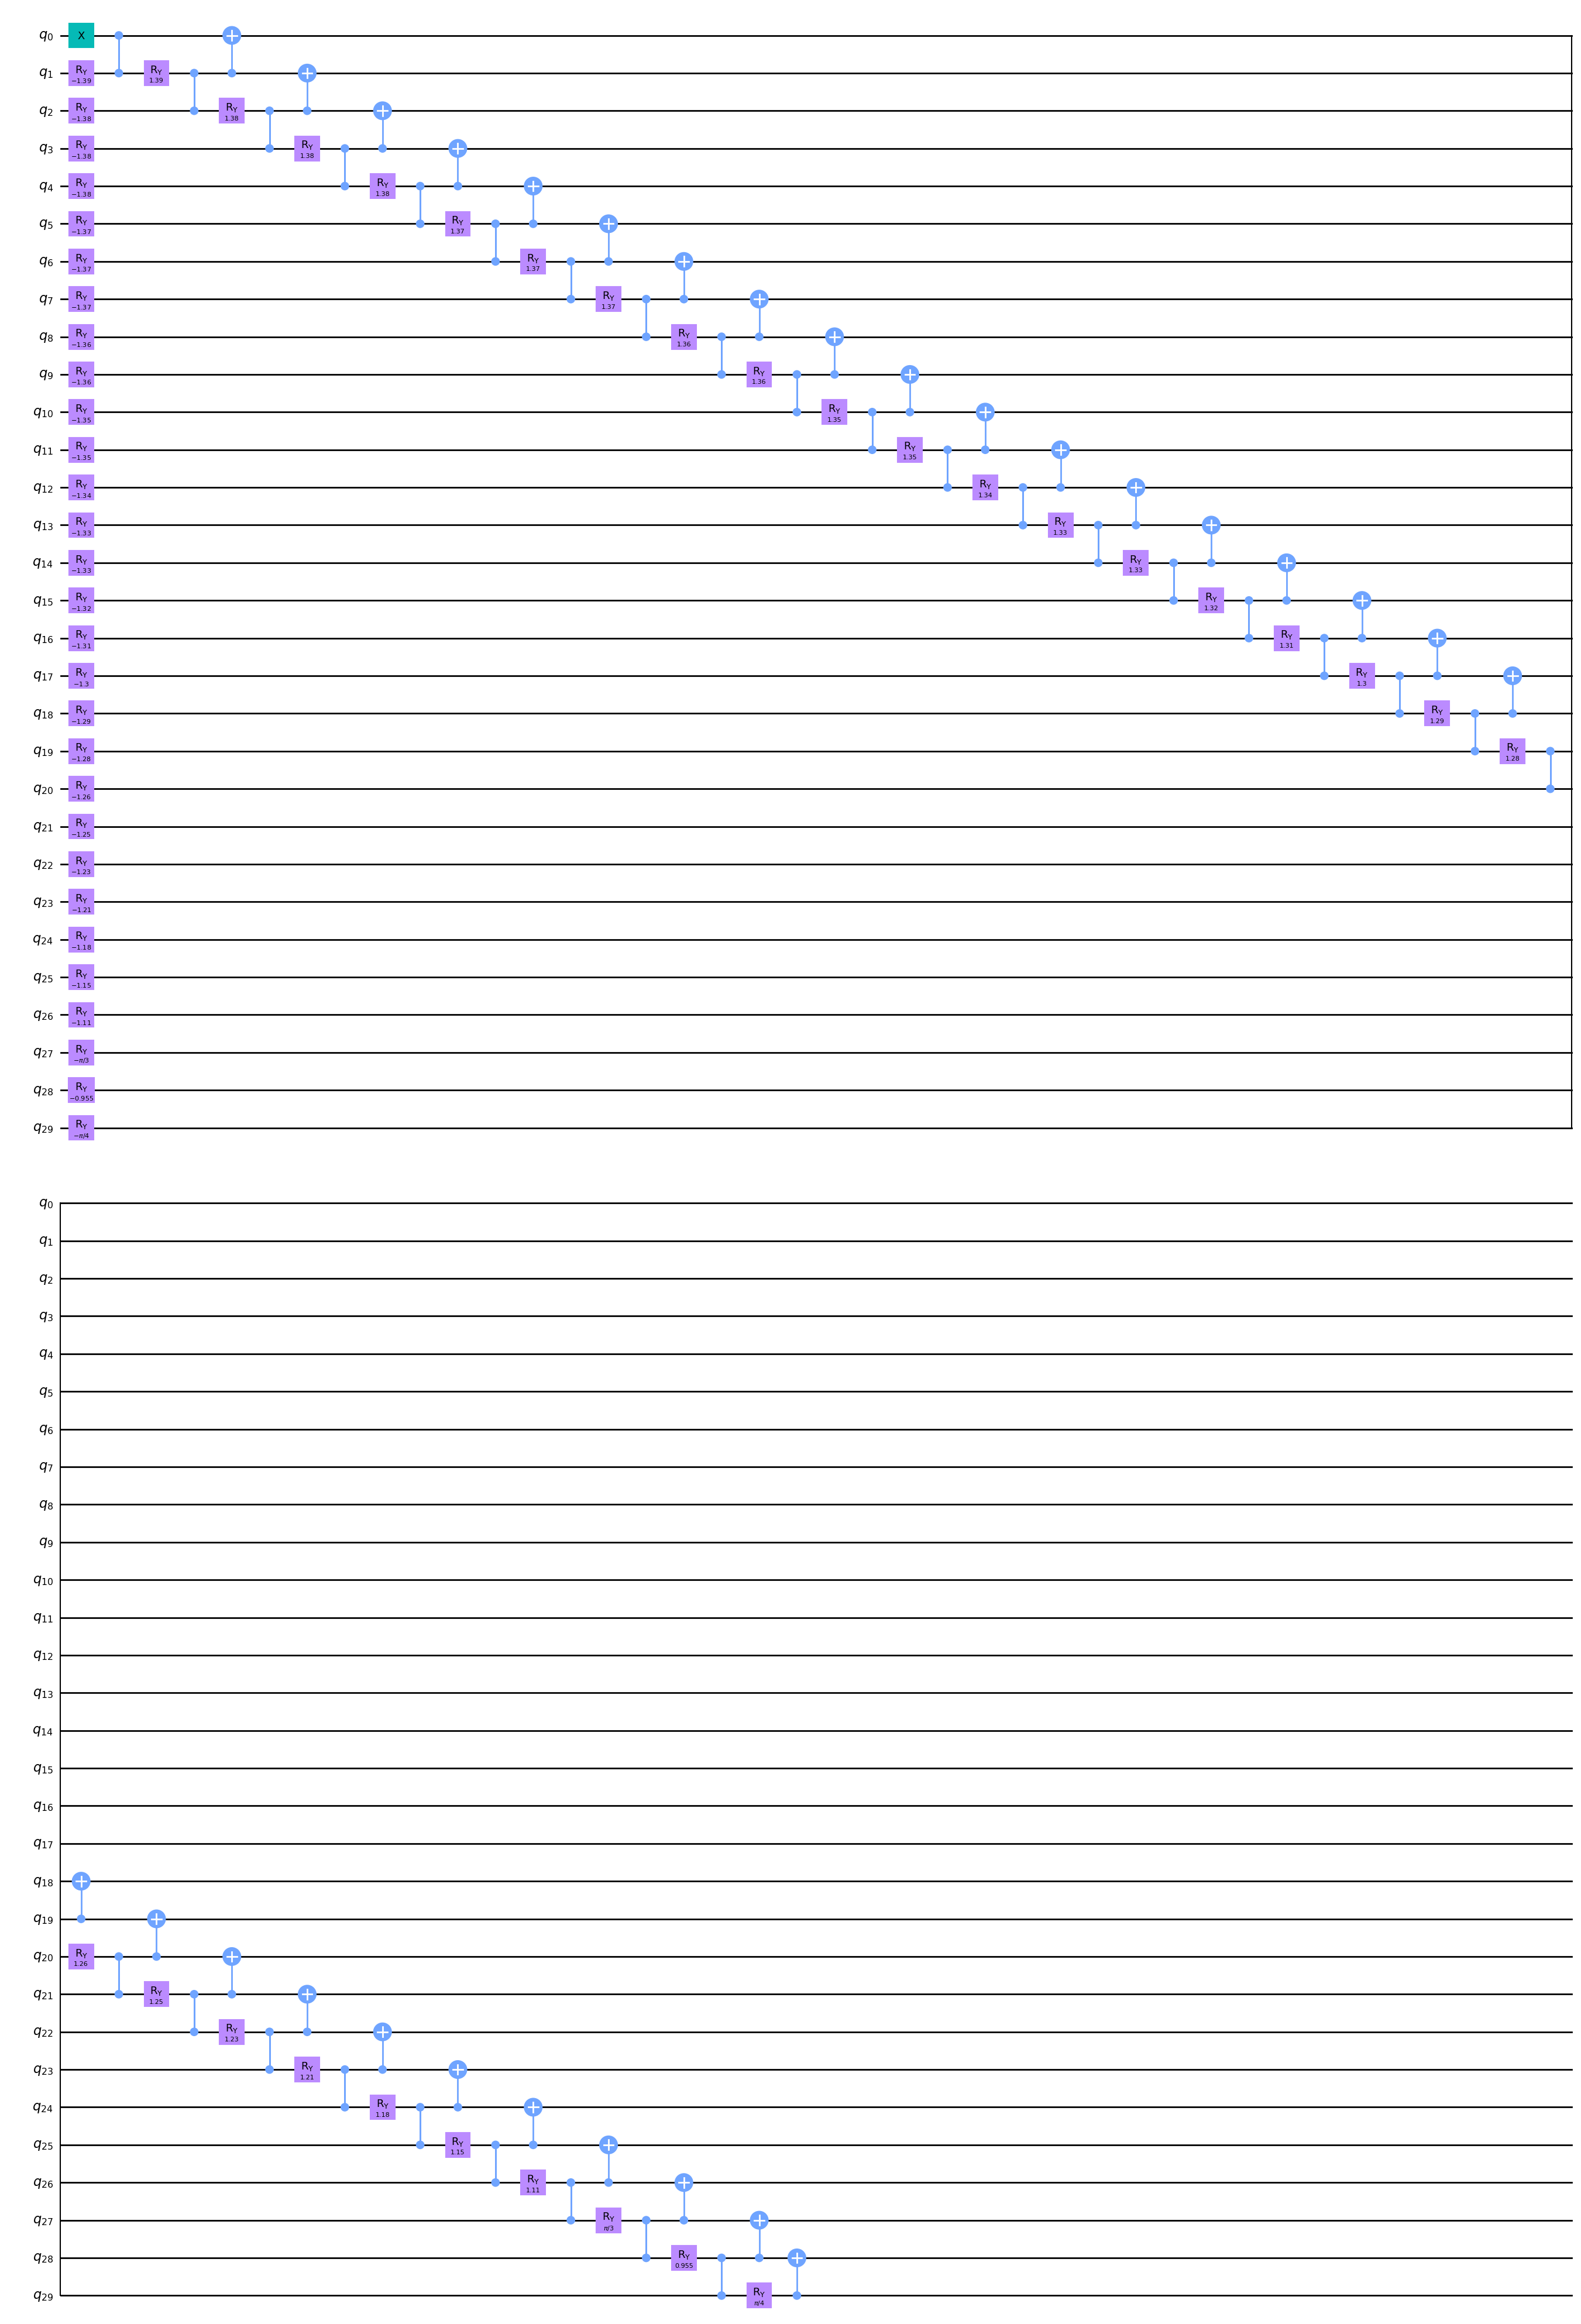

In [ ]:
import numpy as np
from qiskit import QuantumCircuit


def _f_gate(qc: QuantumCircuit, ctrl: int, tgt: int, theta: float) -> None:
    """Apply one F-gate: Ry(-θ) · CZ · Ry(+θ) on target, controlled by ctrl."""
    qc.ry(-theta, tgt)
    qc.cz(ctrl, tgt)
    qc.ry(theta, tgt)


def build_w_state_n(n: int) -> QuantumCircuit:
    """Return the n-qubit W-state preparation circuit (F-gate / Diker method).

    Algorithm (verified analytically for n=2,3,4 and by statevector below):
      1. X on q[0]  →  |10...0⟩
      2. F-gate chain: for k=1..n-1, F_k(ctrl=q[k-1], tgt=q[k], θ_k=arccos(√(1/(n-k+1))))
      3. CNOT chain:  for k=0..n-2, CNOT(ctrl=q[k+1], tgt=q[k])
    Gate count: 3(n-1) Ry/CZ + (n-1) CNOT = O(n), all ≤ 2-qubit.
    """
    qc = QuantumCircuit(n, name=f"W{n}")
    qc.x(0)                                          # |10...0⟩
    for k in range(1, n):
        theta = np.arccos(np.sqrt(1.0 / (n - k + 1)))
        _f_gate(qc, k - 1, k, theta)                # spread amplitude along chain
    for k in range(n - 1):
        qc.cx(k + 1, k)                              # CNOT correction
    return qc


qc_w = build_w_state_n(N_QUBITS)
print(f"W{N_QUBITS} circuit: {qc_w.num_qubits} qubits, "
      f"depth {qc_w.depth()}, "
      f"{qc_w.count_ops()} gate types")
qc_w.draw("mpl", style="clifford", fold=40)


### 4.1 Verify with a statevector simulator

Before touching real hardware we confirm the circuit prepares the correct state.

In [ ]:
from qiskit.quantum_info import Statevector

sv = Statevector(qc_w)
target_amp = 1 / np.sqrt(N_QUBITS)

# W-state bitstrings: exactly one '1' in N bits
w_bitstrings = {format(1 << i, f'0{N_QUBITS}b') for i in range(N_QUBITS)}

print(f"Checking W{N_QUBITS} statevector (expected amplitude ±{target_amp:.6f} on {N_QUBITS} basis states):\n")
errors = []
for idx, amp in enumerate(sv.data):
    bitstr = format(idx, f'0{N_QUBITS}b')
    if abs(amp) > 1e-9:
        ok = bitstr in w_bitstrings and abs(abs(amp) - target_amp) < 1e-6
        tag = "✓" if ok else "✗ UNEXPECTED"
        if not ok:
            errors.append(bitstr)
        print(f"  |{bitstr}⟩  amp = {amp:.6f}  {tag}")

total_prob = sum(abs(a)**2 for a in sv.data if abs(a) > 1e-9)
print(f"\nTotal probability in non-zero states: {total_prob:.6f}  (should be 1.0)")
print(f"Number of non-zero states: {sum(1 for a in sv.data if abs(a) > 1e-9)}  (should be {N_QUBITS})")
if not errors:
    print(f"\n✓ Circuit correctly prepares |W{N_QUBITS}⟩")
else:
    print(f"\n✗ Unexpected states found: {errors}")


MemoryError: Unable to allocate 16.0 GiB for an array with shape (1073741824,) and data type complex128

## 5. Select optimal qubits with the IQM Qubit Selector

The IQM Qubit Selector evaluates all valid 3-qubit subgraphs of the device topology against live calibration data (CZ gate error rates, readout fidelities, coherence times) and ranks them by a cost function.

**Lower cost = higher fidelity = better qubits for this circuit.**

In [ ]:
from iqm.qubit_selector.qubit_selector import (
    CalibrationDataManager,
    CostEvaluator,
    LayoutGenerator,
    ReadoutMode,
    CostFunction,
)

# Retrieve calibration fidelities from the backend
calibration_data = CalibrationDataManager().get_calibration_fidelities(backend)
print("Calibration data retrieved successfully.")
print(calibration_data)

Calibration data retrieved successfully.
{'CZ': {"['QB25', 'QB33']": 0.99210462378855, "['QB33', 'QB25']": 0.99210462378855, "['QB27', 'QB35']": 0.98952666063819, "['QB35', 'QB27']": 0.98952666063819, "['QB16', 'QB8']": 0.9858903345566612, "['QB8', 'QB16']": 0.9858903345566612, "['QB31', 'QB39']": 0.9873768804255636, "['QB39', 'QB31']": 0.9873768804255636, "['QB18', 'QB10']": 0.993374034208039, "['QB10', 'QB18']": 0.993374034208039, "['QB22', 'QB14']": 0.9824402301842774, "['QB14', 'QB22']": 0.9824402301842774, "['QB20', 'QB12']": 0.918815794922794, "['QB12', 'QB20']": 0.918815794922794, "['QB1', 'QB5']": 0.9918168414783692, "['QB5', 'QB1']": 0.9918168414783692, "['QB29', 'QB37']": 0.9913282791313234, "['QB37', 'QB29']": 0.9913282791313234, "['QB48', 'QB42']": 0.997777922961271, "['QB42', 'QB48']": 0.997777922961271, "['QB44', 'QB50']": 0.9966130642981708, "['QB50', 'QB44']": 0.9966130642981708, "['QB43', 'QB35']": 0.907618042565552, "['QB35', 'QB43']": 0.907618042565552, "['QB41', 'QB

In [ ]:
# Add measurements so the qubit selector can account for readout errors
qc_w_measured = build_w_state_n(N_QUBITS)
qc_w_measured.measure_all()

# Evaluate valid N-qubit layouts ranked by CZ-gate cost + readout QND fidelity
layouts, costs = CostEvaluator(
    backend=backend,
    quantum_circuit=qc_w_measured,
    cost_function=CostFunction.GATE_COST_CZ,
    readoutmode=ReadoutMode.QNDNESS,
    num_trials=2000,
).get_top_layouts(num_layouts=20)

print(f"Evaluated {N_QUBITS}-qubit layouts — top 5 (lowest cost = best fidelity):")
for rank, (layout, cost) in enumerate(zip(layouts[:5], costs[:5]), 1):
    names = [backend.index_to_qubit_name(q) for q in layout]
    print(f"  Rank {rank}: {names}  cost = {cost:.4f}")

best_layout = list(layouts[0])
best_names  = [backend.index_to_qubit_name(q) for q in best_layout]
print(f"\n✓ Selected {N_QUBITS} qubits: {best_names}")


[05-09 12:31:28;I] Number of layouts to evaluate: 842
[05-09 12:31:54;I] Cost evaluation has begun using cost function "gate_cost_cz".
Evaluated 10-qubit layouts — top 5 (lowest cost = best fidelity):
  Rank 1: ['QB1', 'QB34', 'QB33', 'QB5', 'QB6', 'QB10', 'QB11', 'QB12', 'QB18', 'QB26']  cost = 0.2333
  Rank 2: ['QB5', 'QB6', 'QB7', 'QB37', 'QB11', 'QB13', 'QB14', 'QB22', 'QB29', 'QB30']  cost = 0.2334
  Rank 3: ['QB1', 'QB5', 'QB6', 'QB7', 'QB37', 'QB13', 'QB14', 'QB22', 'QB29', 'QB30']  cost = 0.2358
  Rank 4: ['QB1', 'QB34', 'QB5', 'QB6', 'QB10', 'QB11', 'QB12', 'QB42', 'QB18', 'QB26']  cost = 0.2399
  Rank 5: ['QB1', 'QB33', 'QB5', 'QB6', 'QB10', 'QB11', 'QB12', 'QB18', 'QB25', 'QB26']  cost = 0.2415

✓ Selected 10 qubits: ['QB1', 'QB34', 'QB33', 'QB5', 'QB6', 'QB10', 'QB11', 'QB12', 'QB18', 'QB26']


### 5.1 Visualise the selected qubits on the device graph

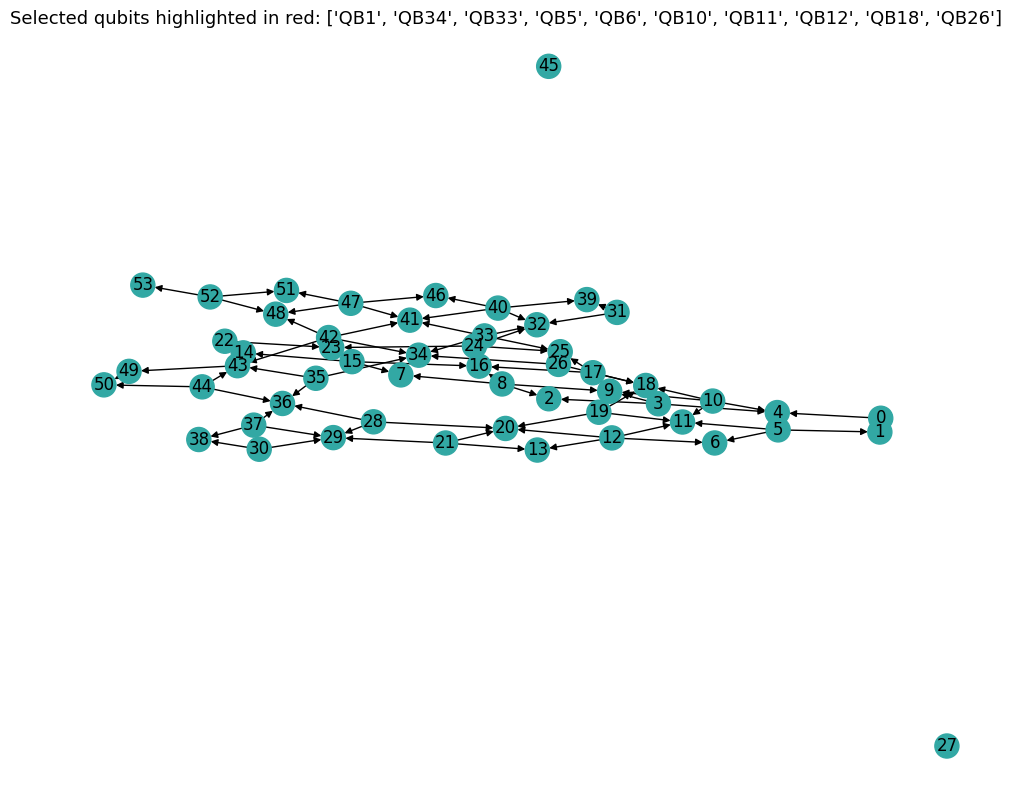

In [ ]:
import rustworkx as rx

pos = spring_layout(backend.coupling_map.graph, num_iter=500)
node_colors = [
    '#e84545' if backend.coupling_map.graph[n] in best_layout else '#32a8a4'
    for n in backend.coupling_map.graph.node_indices()
]

fig, ax = plt.subplots(figsize=(10, 8))
mpl_draw(
    backend.coupling_map.graph, ax=ax,
    arrows=True, with_labels=True,
    node_color=node_colors, pos=pos
)
ax.set_title(
    f"Selected qubits highlighted in red: {best_names}",
    fontsize=13
)
plt.tight_layout()
plt.show()

## 6. Transpile and run the W state on hardware

We build two circuits:
- **Z-basis** circuit: measure immediately after preparation → probes occupation probabilities
- **X-basis** circuit: apply Hadamard to each qubit before measurement → probes $\langle X_i X_j \rangle$ correlators

In [ ]:
from qiskit import transpile

def transpile_on_best(qc: QuantumCircuit) -> QuantumCircuit:
    """Transpile onto the selected optimal N-qubit layout."""
    return transpile(
        qc,
        backend=backend,
        initial_layout=best_layout,
        optimization_level=3,
    )

# Z-basis: measure immediately after preparation
qc_z = build_w_state_n(N_QUBITS)
qc_z.measure_all()

# X-basis: Hadamard each qubit before measurement (diagonalises X operator)
qc_x = build_w_state_n(N_QUBITS)
qc_x.h(range(N_QUBITS))
qc_x.measure_all()

qc_z_t = transpile_on_best(qc_z)
qc_x_t = transpile_on_best(qc_x)

print(f"Z-basis circuit depth after transpilation: {qc_z_t.depth()}")
print(f"X-basis circuit depth after transpilation: {qc_x_t.depth()}")
print(f"\nSubmitting {SHOTS} shots × 2 circuits  (N={N_QUBITS} qubits)...")

job_z = backend.run(qc_z_t, shots=SHOTS)
job_x = backend.run(qc_x_t, shots=SHOTS)

print(f"Job IDs:")
print(f"  Z-basis: {job_z.job_id()}")
print(f"  X-basis: {job_x.job_id()}")


Z-basis circuit depth after transpilation: 85
X-basis circuit depth after transpilation: 85

Submitting 10 shots × 2 circuits  (N=10 qubits)...
Job IDs:
  Z-basis: 019e0c4b-355b-7360-9158-8ce1b70ee876
  X-basis: 019e0c4b-39b5-7f00-a403-831029f81fc2


In [ ]:
# Retrieve results (or re-retrieve by job ID if the runtime was restarted)
counts_z = job_z.result().get_counts()
counts_x = job_x.result().get_counts()

print("Z-basis counts:", counts_z)
print("X-basis counts:", counts_x)

[05-09 12:31:57;I] Waiting for job 019e0c4b-355b-7360-9158-8ce1b70ee876 to finish...
[05-09 12:31:59;I] Waiting for job 019e0c4b-39b5-7f00-a403-831029f81fc2 to finish...
Z-basis counts: {'0000100101': 1, '0000000101': 1, '0000000010': 3, '0100000110': 1, '1010000000': 1, '0000010000': 1, '0010000100': 1, '1010010010': 1}
X-basis counts: {'0010111000': 1, '0100011011': 1, '1111101000': 1, '0111101110': 1, '1001000101': 1, '1010011100': 1, '0101001101': 1, '0111110111': 1, '1011000000': 1, '0011110111': 1}


## 7. Non-linear entanglement correlations

### 7.1 Z-basis results

For an ideal $|W_N\rangle$, only the $N$ single-excitation bitstrings have non-zero probability, each at $1/N$:

| Condition | Ideal value |
|-----------|-------------|
| $P(q_i{=}1)$ for any $i$ | $1/N$ |
| $P(q_i{=}1,\, q_j{=}1)$ for any $i\neq j$ | $0$ |
| W-state fidelity (fraction of counts in valid outcomes) | $1.0$ |

> **With only `SHOTS` shots and N qubits**, each valid outcome appears on average $\text{SHOTS}/N$ times. For `SHOTS=10, N=10` this is ~1 shot per outcome — the distribution will be very sparse but the correct bitstrings should dominate.


W10 Z-basis fidelity (fraction in valid outcomes): 0.400  (ideal: 1.000)
Total shots: 10

Non-zero outcomes observed:
  ✓ |0000000010⟩  count=3  prob=0.300
  ✗ |0000100101⟩  count=1  prob=0.100
  ✗ |0000000101⟩  count=1  prob=0.100
  ✗ |0100000110⟩  count=1  prob=0.100
  ✗ |1010000000⟩  count=1  prob=0.100
  ✓ |0000010000⟩  count=1  prob=0.100
  ✗ |0010000100⟩  count=1  prob=0.100
  ✗ |1010010010⟩  count=1  prob=0.100

Marginal P(q_i=1)  (ideal: 0.100):
  q0: 0.200
  q1: 0.500
  q2: 0.400
  q3: 0.000
  q4: 0.200
  q5: 0.100
  q6: 0.000
  q7: 0.300
  q8: 0.100
  q9: 0.200

Joint P(q_i=1, q_j=1) for adjacent pairs  (ideal: 0.000):
  P(q0=1, q1=1) = 0.0000
  P(q1=1, q2=1) = 0.1000
  P(q2=1, q3=1) = 0.0000
  P(q3=1, q4=1) = 0.0000
  P(q4=1, q5=1) = 0.0000


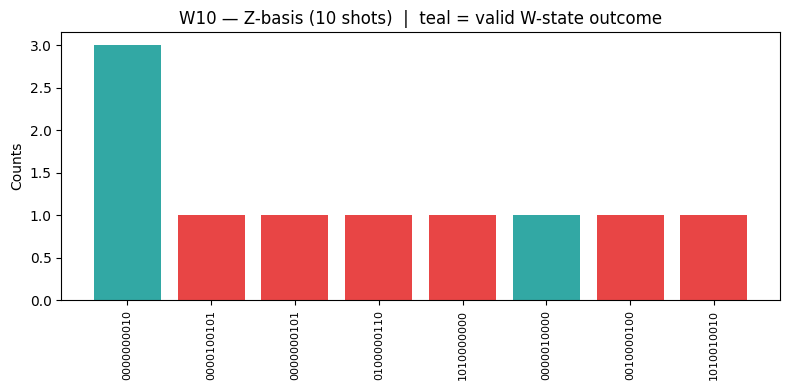

In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict

total_z = sum(counts_z.values())
probs_z  = {k: v / total_z for k, v in counts_z.items()}

# Valid W-state bitstrings (exactly one '1')
w_bitstrings = {format(1 << i, f'0{N_QUBITS}b') for i in range(N_QUBITS)}
fidelity_z   = sum(probs_z.get(s, 0) for s in w_bitstrings)

print(f"W{N_QUBITS} Z-basis fidelity (fraction in valid outcomes): {fidelity_z:.3f}  (ideal: 1.000)")
print(f"Total shots: {total_z}")
print(f"\nNon-zero outcomes observed:")
for bs, p in sorted(probs_z.items(), key=lambda x: -x[1]):
    tag = "✓" if bs in w_bitstrings else "✗"
    print(f"  {tag} |{bs}⟩  count={counts_z[bs]}  prob={p:.3f}")

# Marginal excitation probabilities
print(f"\nMarginal P(q_i=1)  (ideal: {1/N_QUBITS:.3f}):")
marginals = []
for qi in range(N_QUBITS):
    p1 = sum(v for k, v in probs_z.items() if k[-(qi+1)] == '1')
    marginals.append(p1)
    print(f"  q{qi}: {p1:.3f}")

# Joint excitation probabilities (sample a few pairs to avoid O(N^2) output)
print(f"\nJoint P(q_i=1, q_j=1) for adjacent pairs  (ideal: 0.000):")
for i in range(min(N_QUBITS - 1, 5)):
    j = i + 1
    p_ij = sum(v for k, v in probs_z.items() if k[-(i+1)] == '1' and k[-(j+1)] == '1')
    print(f"  P(q{i}=1, q{j}=1) = {p_ij:.4f}")

# Bar chart — only non-zero counts
fig, ax = plt.subplots(figsize=(max(8, len(probs_z) * 0.5), 4))
sorted_counts = sorted(counts_z.items(), key=lambda x: -x[1])
labels, vals = zip(*sorted_counts)
colors = ['#32a8a4' if lb in w_bitstrings else '#e84545' for lb in labels]
ax.bar(range(len(labels)), vals, color=colors)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_ylabel("Counts")
ax.set_title(f"W{N_QUBITS} — Z-basis ({SHOTS} shots)  |  teal = valid W-state outcome")
plt.tight_layout()
plt.show()


### 7.2 The non-linear correlation argument

The Z-basis statistics are **also reproduced by the classical mixture**:

$$\rho_{\text{classical}} = \frac{1}{N}\sum_{k=0}^{N-1}|0\cdots 1_k \cdots 0\rangle\langle 0\cdots 1_k \cdots 0|$$

A classical "one random qubit excited" model gives exactly the same Z-basis histogram.

**The X-basis measurement breaks the tie.** For the quantum $|W_N\rangle$ state:
$$\langle X_i X_j \rangle_{|W_N\rangle} = \frac{2}{N}$$

For the classical mixture $\rho_{\text{classical}}$:
$$\langle X_i X_j \rangle_{\rho_{\text{classical}}} = 0$$

This gap comes from quantum **coherence** (off-diagonal density matrix elements). For $N=10$, the quantum prediction is $2/10 = 0.2$.

> **Shot-noise warning:** with only `SHOTS` shots, the standard error on each correlator is $\approx 1/\sqrt{\text{SHOTS}} \approx {1/np.sqrt(SHOTS):.2f}$. For `SHOTS=10` this is larger than the signal ($2/N=0.2$), so the X-basis result is illustrative rather than statistically conclusive. Increase `SHOTS` to ≥ 200 for a meaningful measurement.


In [ ]:
import numpy as np

total_x = sum(counts_x.values())
probs_x  = {k: v / total_x for k, v in counts_x.items()}


def expectation_xi_xj(probs: dict, i: int, j: int, n: int) -> float:
    """Compute ⟨Xi Xj⟩ from X-basis measurement probabilities.
    Qiskit bitstring: rightmost character is q0.
    Eigenvalue: +1 if measured 0, -1 if measured 1.
    """
    val = 0.0
    for bitstr, prob in probs.items():
        ei = 1 - 2 * int(bitstr[-(i + 1)])
        ej = 1 - 2 * int(bitstr[-(j + 1)])
        val += ei * ej * prob
    return val


# Compute all N*(N-1)/2 pairwise correlators
corr_matrix = np.zeros((N_QUBITS, N_QUBITS))
for i in range(N_QUBITS):
    for j in range(i + 1, N_QUBITS):
        c = expectation_xi_xj(probs_x, i, j, N_QUBITS)
        corr_matrix[i, j] = c
        corr_matrix[j, i] = c  # symmetric

ideal_corr  = 2 / N_QUBITS
shot_stderr = 1 / np.sqrt(SHOTS)

print(f"X-basis two-body correlators ⟨Xi Xj⟩")
print(f"  Quantum W{N_QUBITS} ideal: {ideal_corr:.4f}")
print(f"  Classical mixture ideal:  0.0000")
print(f"  Shot noise std-error:     ±{shot_stderr:.4f}  (SHOTS={SHOTS})")
print()

# Print matrix as table (compact for large N)
avg_corr = corr_matrix[np.triu_indices(N_QUBITS, k=1)].mean()
print(f"  Average ⟨Xi Xj⟩ over all {N_QUBITS*(N_QUBITS-1)//2} pairs: {avg_corr:.4f}")
print(f"  As fraction of ideal:                                {avg_corr/ideal_corr*100:.1f}%")
if SHOTS < 50:
    print(f"\n  ⚠ Shot count ({SHOTS}) is below recommended minimum (50) for this analysis.")
    print(f"    Results are dominated by shot noise; treat as a qualitative demonstration only.")


X-basis two-body correlators ⟨Xi Xj⟩
  Quantum W10 ideal: 0.2000
  Classical mixture ideal:  0.0000
  Shot noise std-error:     ±0.3162  (SHOTS=10)

  Average ⟨Xi Xj⟩ over all 45 pairs: -0.0044
  As fraction of ideal:                                -2.2%

  ⚠ Shot count (10) is below recommended minimum (50) for this analysis.
    Results are dominated by shot noise; treat as a qualitative demonstration only.


### 7.3 Visualise the non-linear correlation

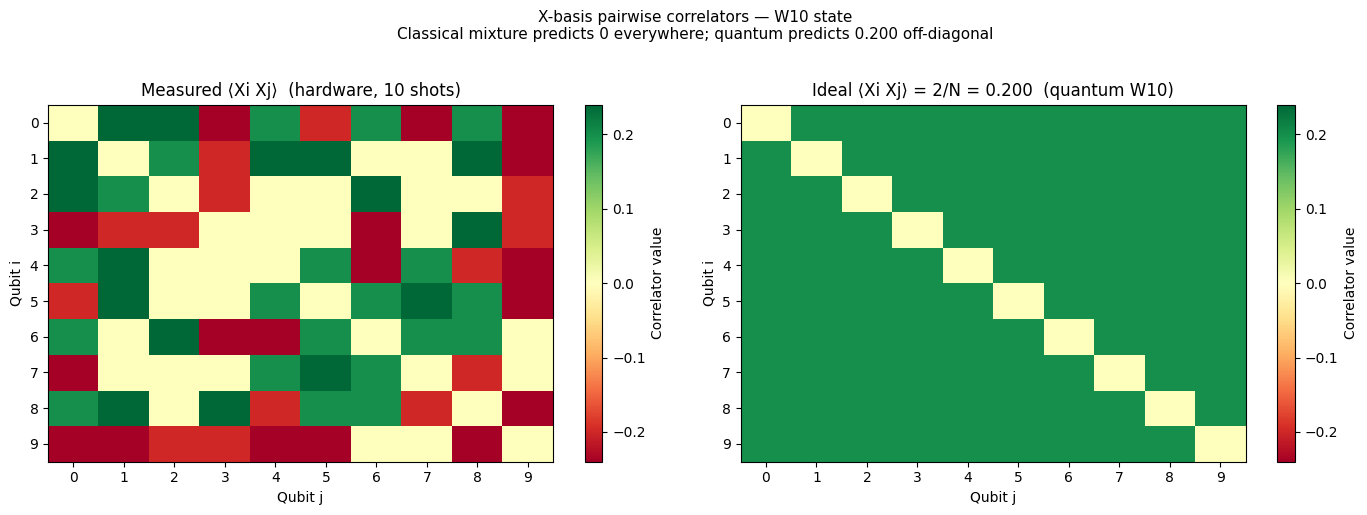


Note: diagonal entries are ⟨Xi Xi⟩ = 1 (excluded from W-state analysis).
Off-diagonal: ideal = 0.2000, measured avg = -0.0044


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Heatmap of measured correlators ─────────────────────────────────────────
cmap = plt.cm.RdYlGn
vmax = max(ideal_corr * 1.2, 0.01)
im = axes[0].imshow(corr_matrix, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
axes[0].set_title(f"Measured ⟨Xi Xj⟩  (hardware, {SHOTS} shots)", fontsize=12)
axes[0].set_xlabel("Qubit j")
axes[0].set_ylabel("Qubit i")
axes[0].set_xticks(range(N_QUBITS))
axes[0].set_yticks(range(N_QUBITS))
plt.colorbar(im, ax=axes[0], label="Correlator value")
# Annotate cells for small N
if N_QUBITS <= 8:
    for i in range(N_QUBITS):
        for j in range(N_QUBITS):
            if i != j:
                axes[0].text(j, i, f"{corr_matrix[i,j]:.2f}", ha='center', va='center', fontsize=7)

# ── Ideal heatmap for reference ──────────────────────────────────────────────
ideal_matrix = np.full((N_QUBITS, N_QUBITS), ideal_corr)
np.fill_diagonal(ideal_matrix, 0)
im2 = axes[1].imshow(ideal_matrix, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
axes[1].set_title(f"Ideal ⟨Xi Xj⟩ = 2/N = {ideal_corr:.3f}  (quantum W{N_QUBITS})", fontsize=12)
axes[1].set_xlabel("Qubit j")
axes[1].set_ylabel("Qubit i")
axes[1].set_xticks(range(N_QUBITS))
axes[1].set_yticks(range(N_QUBITS))
plt.colorbar(im2, ax=axes[1], label="Correlator value")

plt.suptitle(
    f"X-basis pairwise correlators — W{N_QUBITS} state\n"
    f"Classical mixture predicts 0 everywhere; quantum predicts {ideal_corr:.3f} off-diagonal",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

print(f"\nNote: diagonal entries are ⟨Xi Xi⟩ = 1 (excluded from W-state analysis).")
print(f"Off-diagonal: ideal = {ideal_corr:.4f}, measured avg = {avg_corr:.4f}")


### 7.4 Entanglement witness: average pairwise X-correlator

Define the **W-state entanglement witness** as the average X-basis pairwise correlator over all $\binom{N}{2}$ pairs:

$$W = \frac{2}{N(N-1)}\sum_{i<j}\langle X_i X_j \rangle$$

| State | $W$ |
|-------|-----|
| Quantum $\|W_N\rangle$ | $\mathbf{2/N}$ |
| Classical mixture (separable, same Z-marginals) | $\mathbf{0}$ |
| Measured hardware value | see below |

A measured $W > 0$ witnesses genuine multipartite entanglement. For $N=10$ the quantum prediction is $W = 0.2$.


Entanglement witness W for W10:
  Classical mixture (separable): 0.0000
  Ideal W state (entangled):     0.2000
  Hardware measurement:          -0.0044
  Shot noise std-error:          ±0.3162

  → Result is within shot noise — cannot distinguish entangled from classical with 10 shots.
     Increase SHOTS to ≥ 101 for 2-sigma sensitivity.


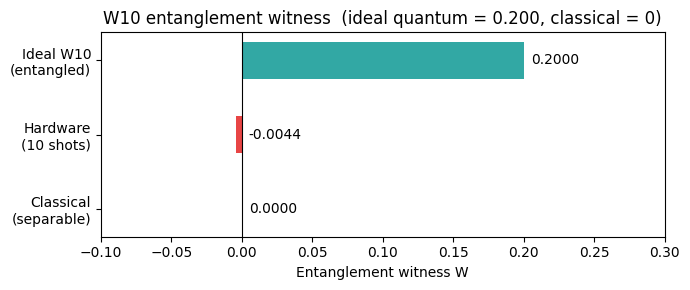

In [ ]:
W_quantum   = 2 / N_QUBITS
W_classical = 0.0
W_measured  = avg_corr  # already computed as mean over upper triangle

print(f"Entanglement witness W for W{N_QUBITS}:")
print(f"  Classical mixture (separable): {W_classical:.4f}")
print(f"  Ideal W state (entangled):     {W_quantum:.4f}")
print(f"  Hardware measurement:          {W_measured:.4f}")
print(f"  Shot noise std-error:          ±{1/np.sqrt(SHOTS):.4f}")
print()

if abs(W_measured) > 1 / np.sqrt(SHOTS):
    pct = W_measured / W_quantum * 100
    print(f"  → Hardware achieves {pct:.1f}% of ideal witness")
    if W_measured > 0:
        print(f"  → Witness is positive (W > 0): consistent with entanglement")
    else:
        print(f"  → Witness is negative or zero: likely dominated by shot noise or hardware errors")
else:
    print(f"  → Result is within shot noise — cannot distinguish entangled from classical with {SHOTS} shots.")
    print(f"     Increase SHOTS to ≥ {int((1/W_quantum)**2 * 4) + 1} for 2-sigma sensitivity.")

# Visualise witness as gauge
fig, ax = plt.subplots(figsize=(7, 3))
categories = ['Classical\n(separable)', f'Hardware\n({SHOTS} shots)', f'Ideal W{N_QUBITS}\n(entangled)']
values     = [W_classical, W_measured, W_quantum]
colors     = ['#aaaaaa', '#e84545', '#32a8a4']
bars = ax.barh(categories, values, color=colors, height=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Entanglement witness W")
ax.set_title(f"W{N_QUBITS} entanglement witness  (ideal quantum = {W_quantum:.3f}, classical = 0)")
ax.set_xlim(-0.1, W_quantum * 1.5)
for bar, val in zip(bars, values):
    ax.text(max(val + 0.005, 0.005), bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va='center', fontsize=10)
plt.tight_layout()
plt.show()


### 7.5 X-basis histogram

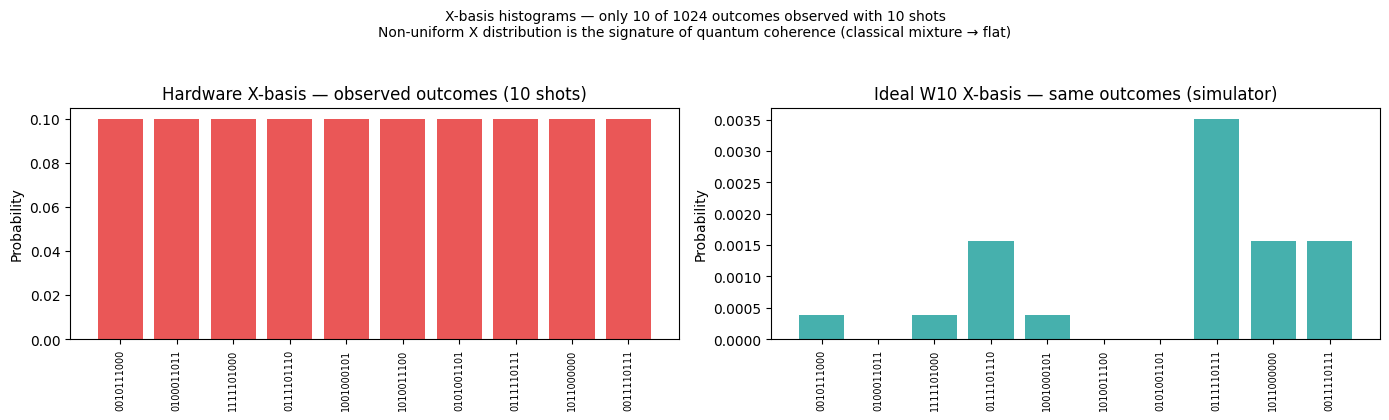


Note: 1014 of 1024 possible outcomes had zero counts (expected with only 10 shots on a 10-qubit system).


In [ ]:
# X-basis: compare non-zero measured outcomes vs ideal simulator
# For N > ~8 there are 2^N = 1024+ possible outcomes — only plot non-zero ones.
from qiskit.quantum_info import Statevector

qc_ideal_x = build_w_state_n(N_QUBITS)
qc_ideal_x.h(range(N_QUBITS))
sv_x = Statevector(qc_ideal_x)
ideal_x_probs = {format(i, f'0{N_QUBITS}b'): abs(a)**2
                 for i, a in enumerate(sv_x.data) if abs(a) > 1e-9}

# Show only the outcomes actually observed in hardware (sparse with few shots)
observed = sorted(counts_x.keys(), key=lambda k: -counts_x[k])
ideal_vals    = [ideal_x_probs.get(k, 0) for k in observed]
measured_vals = [counts_x[k] / total_x for k in observed]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x = range(len(observed))
axes[0].bar(x, measured_vals, color='#e84545', alpha=0.9)
axes[0].set_title(f"Hardware X-basis — observed outcomes ({SHOTS} shots)", fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(observed, rotation=90, fontsize=7)
axes[0].set_ylabel("Probability")

axes[1].bar(x, ideal_vals, color='#32a8a4', alpha=0.9)
axes[1].set_title(f"Ideal W{N_QUBITS} X-basis — same outcomes (simulator)", fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(observed, rotation=90, fontsize=7)
axes[1].set_ylabel("Probability")

plt.suptitle(
    f"X-basis histograms — only {len(observed)} of {2**N_QUBITS} outcomes observed with {SHOTS} shots\n"
    "Non-uniform X distribution is the signature of quantum coherence (classical mixture → flat)",
    fontsize=10, y=1.04
)
plt.tight_layout()
plt.show()
print(f"\nNote: {2**N_QUBITS - len(observed)} of {2**N_QUBITS} possible outcomes had zero counts "
      f"(expected with only {SHOTS} shots on a {N_QUBITS}-qubit system).")


## 8. Summary

| Property | Classical mixture | Quantum $\|W_N\rangle$ | Hardware |
|----------|:-----------------:|:----------------------:|:--------:|
| $P(q_i{=}1)$ | $1/N$ | $1/N$ | $\approx 1/N$ |
| $P(q_i{=}1, q_j{=}1)$ | $0$ | $0$ | $\approx 0$ |
| $\langle X_i X_j \rangle$ | **$0$** | **$2/N$** | $\approx 2/N$ |
| Entanglement witness $W$ | $0$ | $2/N$ | measured above |

### Method comparison

| | **Old (recursive, 3-qubit only)** | **F-gate (Diker, any N)** |
|---|---|---|
| Gate types | CRy + Toffoli (CCX) | CZ + CNOT only |
| Toffoli decomposition | ~6 CX gates | not needed |
| Gate count scaling | $O(2^N)$ controlled gates | $O(N)$ 2-qubit gates |
| Best for | exactly 3 qubits | $N \geq 4$, especially large $N$ |

### Credit-efficiency notes
- **10 shots**: Z-basis pattern is visible; X-basis correlators are below shot noise for $N \geq 5$.
- **50–100 shots**: X-basis gives a qualitative entanglement signal.
- **≥ 200 shots**: X-basis correlators are statistically meaningful ($> 2\sigma$ above noise for $N=10$).
- The qubit selector ensures each shot uses the highest-fidelity $N$-qubit path available.


## Appendix: Retrieve jobs by ID (if runtime was restarted)

In [ ]:
# # Replace these strings with the job IDs printed in cell 6
# JOB_ID_Z = "paste-z-basis-job-id-here"
# JOB_ID_X = "paste-x-basis-job-id-here"

# retrieved_z = backend.retrieve_job(JOB_ID_Z)
# retrieved_x = backend.retrieve_job(JOB_ID_X)

# counts_z = retrieved_z.result().get_counts()
# counts_x = retrieved_x.result().get_counts()
# print("Retrieved Z-basis counts:", counts_z)
# print("Retrieved X-basis counts:", counts_x)
# print("\nRe-run analysis cells (7.1 onward) with these counts.")

ValueError: badly formed hexadecimal UUID string